In [64]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FuncFormatter
import pandas as pd
import numpy as np
import re

In [65]:
# Style
mpl.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman"],
    "font.size":        11,
    "axes.labelsize":   12,
    "axes.titlesize":   13,
    "legend.fontsize":  10,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "axes.linewidth":   0.8,
    "grid.linewidth":   0.5,
    "lines.linewidth":  1.8,
    "lines.markersize": 6,
    "figure.dpi":       150,
    "savefig.dpi":      300,
    "savefig.bbox":     "tight",
})
 
colors  = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
linestyles  = ["-", "--", ":"]


In [109]:
path = os.path.join(os.getcwd(), "../scaling_results/scaling_grid_results.json")
with open(path, "r") as f:
    data = json.load(f)
    tokens = list(data.keys())
    params = list(data[tokens[0]].keys())


In [110]:
def parse_size(s):
    suffixes = {"K": 1e3, "M": 1e6, "B": 1e9, "T": 1e12}
    return float(s[:-1]) * suffixes.get(s[-1].upper(), 1)
model_types = sorted(set(p.split("_")[0] for p in params))
param_sizes = sorted(set(data[tokens[0]][params[i]]['non_emb_params'] for i in range(len(tokens))))
token_sizes = sorted(set(data[tokens[i]][params[0]]['tokens_seen'] for i in range(len(tokens))))
params_org = [params[i:i+5] for i in range(0, len(params), 5)]
p_dct = {param : (param_sizes + param_sizes + param_sizes)[i] for i, param in enumerate(params)}
t_dct = {token : token_sizes[i] for i, token in enumerate(tokens)}
params = sorted(set(param.split("_")[1] for param in params))
arch_labels = {"dd": "Double Decoder", "sed": "SED", "dec": "Decoder"}
def millions_fmt(x, pos):
    return f"{x/1e6:.0f}M" if x >= 1e6 else f"{x:.0f}"
def flops_fmt(x, pos):
    exp = int(np.log10(x))
    return f"$10^{{{exp}}}$"

print(t_dct)
print(p_dct)
print(tokens)
print(params)
print(params_org)
print(param_sizes)
print(token_sizes)
print(model_types)

{'10M': 9437184, '50M': 49283072, '100M': 99614720, '300M': 299892736, '600M': 599785472}
{'dd_0.6M': 591616, 'dd_2.4M': 2362880, 'dd_5.3M': 5313792, 'dd_14.7M': 14754560, 'dd_28.9M': 28913920, 'sed_0.6M': 591616, 'sed_2.4M': 2362880, 'sed_5.3M': 5313792, 'sed_14.7M': 14754560, 'sed_28.9M': 28913920, 'dec_0.6M': 591616, 'dec_2.4M': 2362880, 'dec_5.3M': 5313792, 'dec_14.7M': 14754560, 'dec_28.9M': 28913920}
['10M', '50M', '100M', '300M', '600M']
['0.6M', '14.7M', '2.4M', '28.9M', '5.3M']
[['dd_0.6M', 'dd_2.4M', 'dd_5.3M', 'dd_14.7M', 'dd_28.9M'], ['sed_0.6M', 'sed_2.4M', 'sed_5.3M', 'sed_14.7M', 'sed_28.9M'], ['dec_0.6M', 'dec_2.4M', 'dec_5.3M', 'dec_14.7M', 'dec_28.9M']]
[591616, 2362880, 5313792, 14754560, 28913920]
[9437184, 49283072, 99614720, 299892736, 599785472]
['dd', 'dec', 'sed']


In [96]:
print(data[tokens[0]][params[0]].keys())

dict_keys(['final_eval_loss', 'final_eval_ppl', 'total_steps', 'tokens_seen', 'total_params', 'non_emb_params', 'training_time_sec', 'model_type', 'hparams', 'train_curve', 'eval_curve', 'aggregate_mfu_pct'])


In [ ]:
def compute_flops(entry: dict) -> float:
    """
    Compute total forward+backward FLOPs for one run using architecture-aware formulas.
    All formulas use the multiply-add = 2 FLOPs convention, times 3 for fwd+bwd.

    Decoder-only:   3L (24Td² + 4T²d)
    Encoder-Decoder (SED):
        encoder: L_enc = 2L/3, decoder: L_dec = L/3
        T1 = T (full seq), T2 = a*T (corrupted/decoder seq, a=0.25 assumed)
        total = (L/3)[(52T1 + 28T2)d² + (8T1² + 4T1T2 + 4T2²)d]
    Double Decoder:
        first dec: 2L/3 layers, second dec: L/3 layers
        total = (L/3)(76Td² + 16T²d)

    L here is num_decoder_layers (the smallest block), so total layers = 3L.
    """
    h  = entry["hparams"]
    d  = h["dim"]
    T  = h["seq_len"]
    L  = h["num_decoder_layers"]   # = L/3 in our notation; total layers = 3L
    N  = entry["tokens_seen"]
    mt = entry["model_type"]

    if mt == "dec":
        # 3L(24Td² + 4T²d), times N tokens
        per_token = 3 * L * (24 * T * d**2 + 4 * T**2 * d)

    elif mt == "sed":
        # corruption rate a = 0.15
        a  = 0.15
        T1 = T
        T2 = int(a * T)
        per_token = (L / 3) * (
            (52 * T1 + 28 * T2) * d**2
            + (8 * T1**2 + 4 * T1 * T2 + 4 * T2**2) * d
        ) * 3   # *3 for fwd+bwd, applied outside the L/3 prefactor

    elif mt == "dd":
        # (L/3)(76Td² + 16T²d), times 3 for fwd+bwd
        per_token = (L / 3) * (76 * T * d**2 + 16 * T**2 * d) * 3

    else:
        raise ValueError(f"Unknown model_type: {mt}")

    return per_token * N

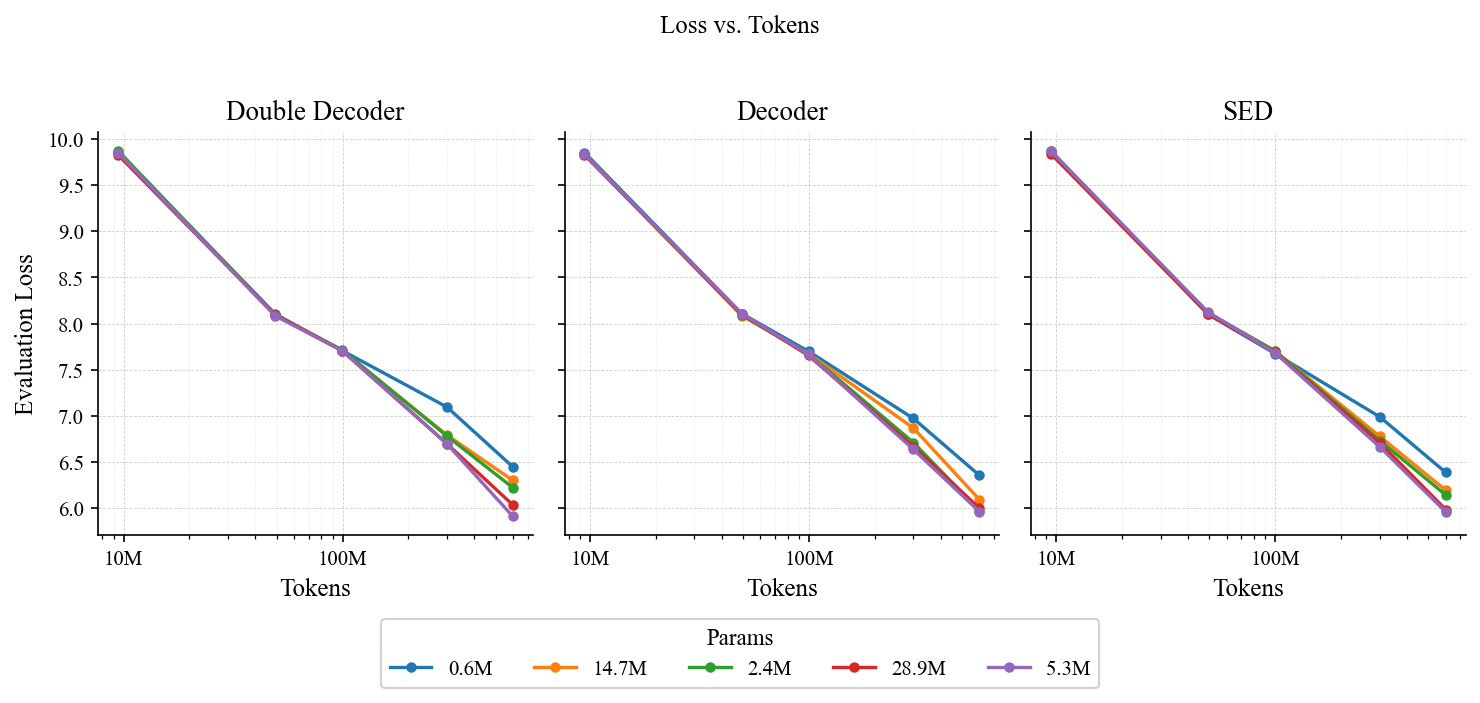

In [123]:
# For fixed parameter sizes, plot loss vs number of tokens
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)
  
for ax, model_type, param_type in zip(axes, model_types, params_org):
    for i, size_label in enumerate(param_type):
        losses = [data[token][size_label]["final_eval_loss"] for token in tokens]
        ax.plot(
            token_sizes, losses,
            color=colors[i],
            marker="o",
            markersize=4,
            linewidth=1.6,
            label=size_label,
        )
    ax.set_title(arch_labels.get(model_type, model_type))
    ax.set_xlabel("Tokens")
    ax.set_xscale("log")
    ax.grid(True, which="both",  linestyle="--", linewidth=0.4, alpha=0.6)
    ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.set_major_formatter(FuncFormatter(millions_fmt))
 
axes[0].set_ylabel("Evaluation Loss")
 
# Shared legend below all subplots
handles, _ = axes[0].get_legend_handles_labels()
fig.legend(
    handles, params,
    title="Params",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=True, framealpha=0.9, edgecolor="0.8",
)
 
fig.suptitle("Loss vs. Tokens", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


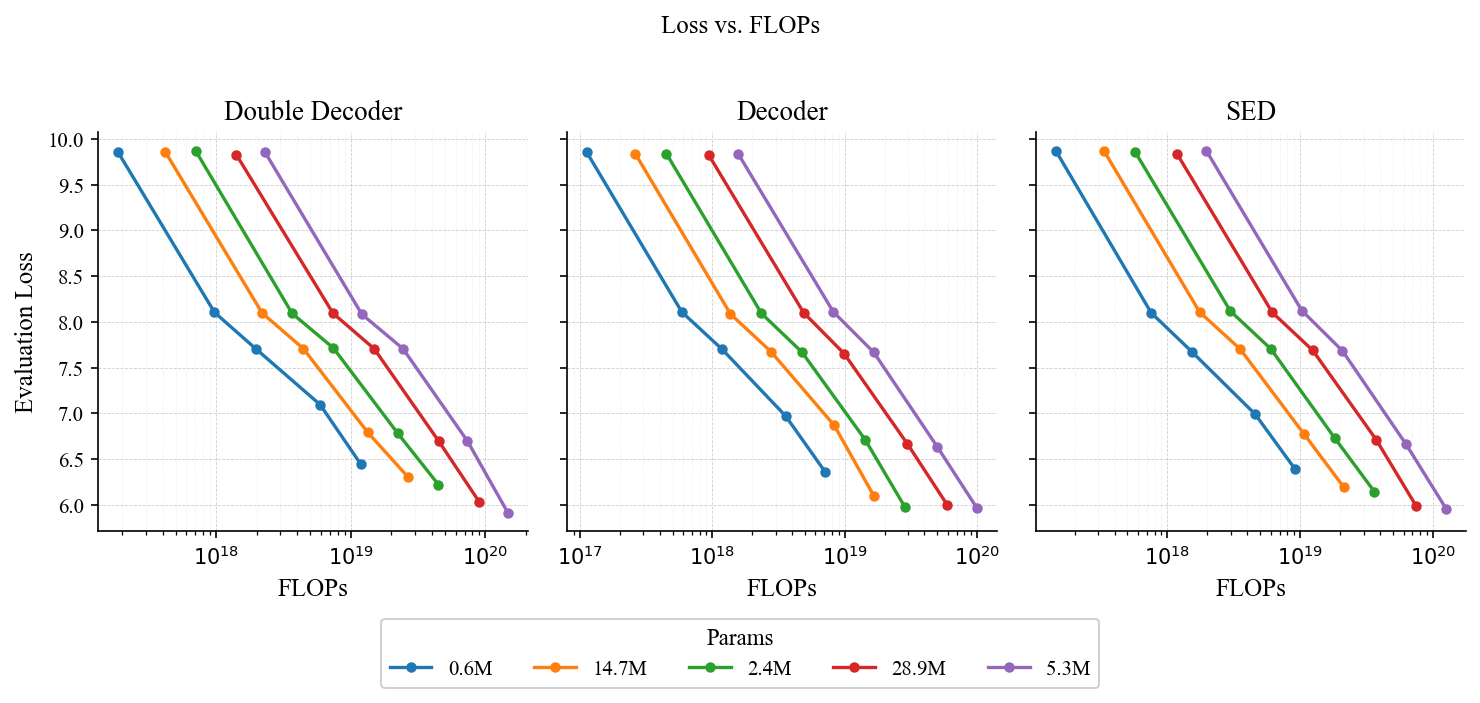

In [135]:
# For fixed parameter sizes, plot loss vs FLOP count
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)
  
for ax, model_type, param_type in zip(axes, model_types, params_org):
    for i, size_label in enumerate(param_type):
        losses = [data[token][size_label]["final_eval_loss"] for token in tokens]
        flops = [compute_flops(data[token][size_label]) for token in tokens]
        ax.plot(
            flops, losses,
            color=colors[i],
            marker="o",
            markersize=4,
            linewidth=1.6,
            label=size_label,
        )
    ax.set_title(arch_labels.get(model_type, model_type))
    ax.set_xlabel("FLOPs")
    ax.set_xscale("log")
    ax.grid(True, which="both",  linestyle="--", linewidth=0.4, alpha=0.6)
    ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.set_major_formatter(FuncFormatter(flops_fmt))
 
axes[0].set_ylabel("Evaluation Loss")
 
# Shared legend below all subplots
handles, _ = axes[0].get_legend_handles_labels()
fig.legend(
    handles, params,
    title="Params",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=True, framealpha=0.9, edgecolor="0.8",
)
 
fig.suptitle("Loss vs. FLOPs", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


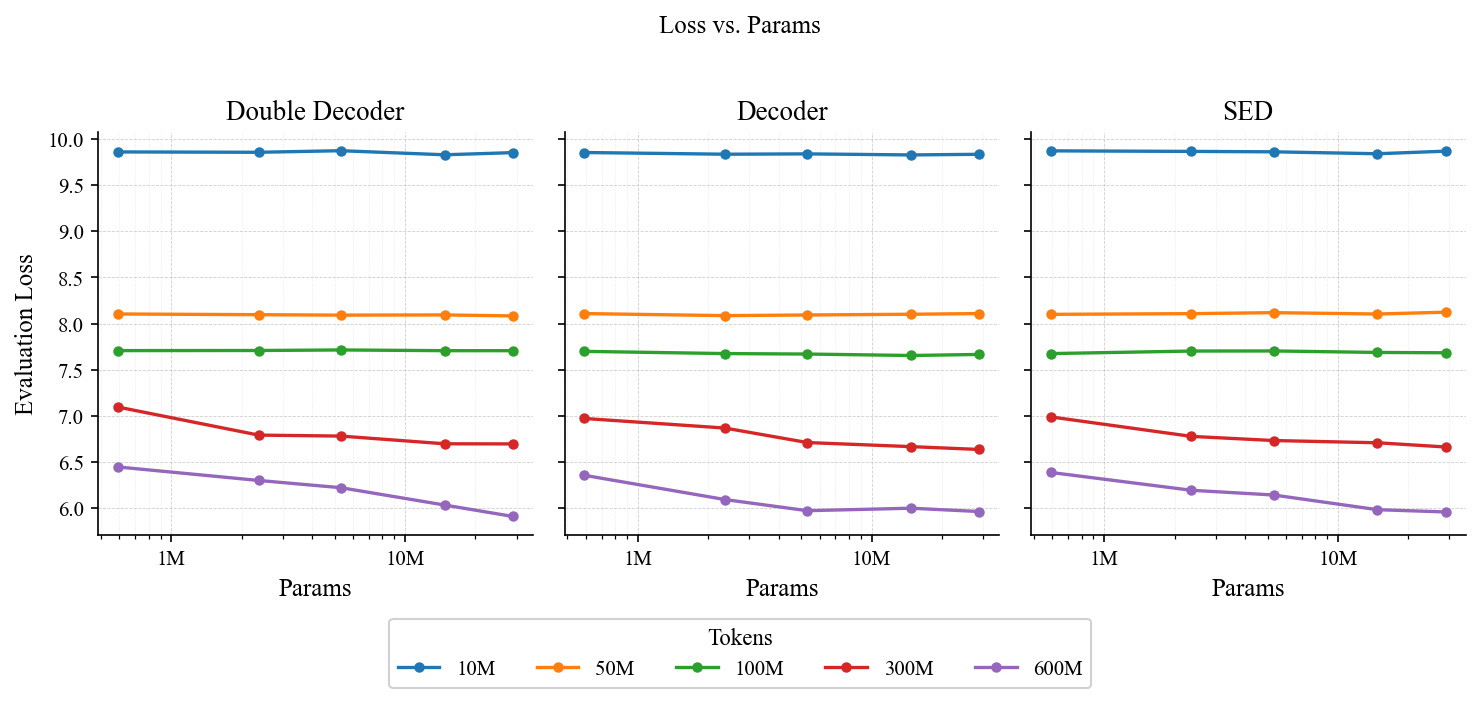

In [125]:
# For fixed numbers of tokens, plot loss vs parameter size
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)
  
for ax, model_type, param_type in zip(axes, model_types, params_org):
    for i, token_budget in enumerate(tokens):
        losses = [data[token_budget][size_label]["final_eval_loss"] for size_label in param_type]
        ax.plot(
            param_sizes, losses,
            color=colors[i],
            marker="o",
            markersize=4,
            linewidth=1.6,
            label=token_budget,
        )
    ax.set_title(arch_labels.get(model_type, model_type))
    ax.set_xlabel("Params")
    ax.set_xscale("log")
    ax.grid(True, which="both",  linestyle="--", linewidth=0.4, alpha=0.6)
    ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.set_major_formatter(FuncFormatter(millions_fmt))
 
axes[0].set_ylabel("Evaluation Loss")
 
# Shared legend below all subplots
handles, _ = axes[0].get_legend_handles_labels()
fig.legend(
    handles, tokens,
    title="Tokens",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=True, framealpha=0.9, edgecolor="0.8",
)
 
fig.suptitle("Loss vs. Params", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


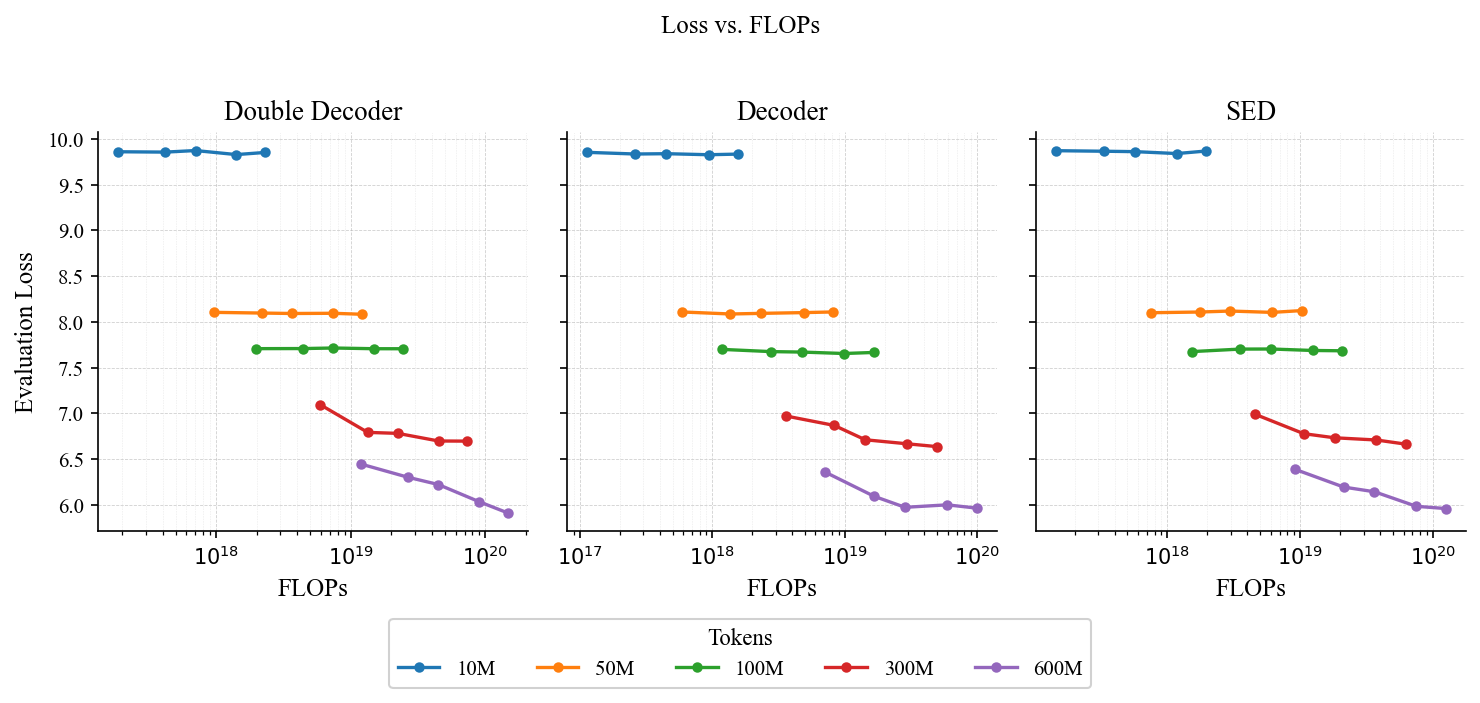

In [136]:
# For fixed numbers of tokens, plot loss vs FLOP count
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)
  
for ax, model_type, param_type in zip(axes, model_types, params_org):
    for i, token_budget in enumerate(tokens):
        losses = [data[token_budget][size_label]["final_eval_loss"] for size_label in param_type]
        flops = [compute_flops(data[token_budget][size_label]) for size_label in param_type]
        ax.plot(
            flops, losses,
            color=colors[i],
            marker="o",
            markersize=4,
            linewidth=1.6,
            label=token_budget,
        )
    ax.set_title(arch_labels.get(model_type, model_type))
    ax.set_xlabel("FLOPs")
    ax.set_xscale("log")
    ax.grid(True, which="both",  linestyle="--", linewidth=0.4, alpha=0.6)
    ax.grid(True, which="minor", linestyle=":",  linewidth=0.3, alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.xaxis.set_major_formatter(FuncFormatter(flops_fmt))
 
axes[0].set_ylabel("Evaluation Loss")
 
# Shared legend below all subplots
handles, _ = axes[0].get_legend_handles_labels()
fig.legend(
    handles, tokens,
    title="Tokens",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    frameon=True, framealpha=0.9, edgecolor="0.8",
)
 
fig.suptitle("Loss vs. FLOPs", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


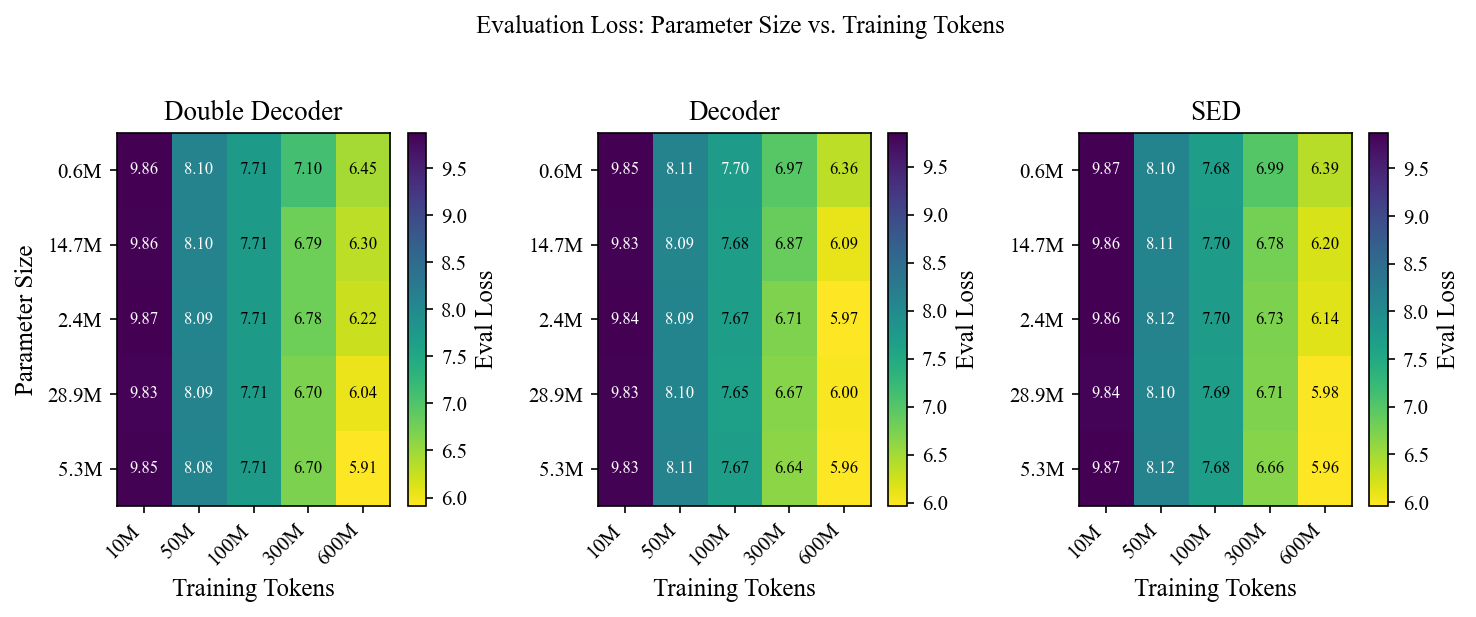

In [127]:
# Plot loss on a parameter size vs number of tokens heatmap
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

for ax, model_type, param_type in zip(axes, model_types, params_org):
    matrix = np.array([
        [data[token][size_label]["final_eval_loss"] for token in tokens]
        for size_label in param_type
    ])
    im = ax.imshow(matrix, aspect="auto", cmap="viridis_r")
    for r in range(len(param_type)):
        for c in range(len(tokens)):
            ax.text(c, r, f"{matrix[r, c]:.2f}", ha="center", va="center",
                    fontsize=8, color="white" if matrix[r, c] > matrix.mean() else "black")
    ax.set_xticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=45, ha="right")
    ax.set_yticks(range(len(param_type)))
    ax.set_yticklabels(params)
    ax.set_xlabel("Training Tokens")
    ax.set_title(arch_labels.get(model_type, model_type))
    fig.colorbar(im, ax=ax, label="Eval Loss")

axes[0].set_ylabel("Parameter Size")
fig.suptitle("Evaluation Loss: Parameter Size vs. Training Tokens", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

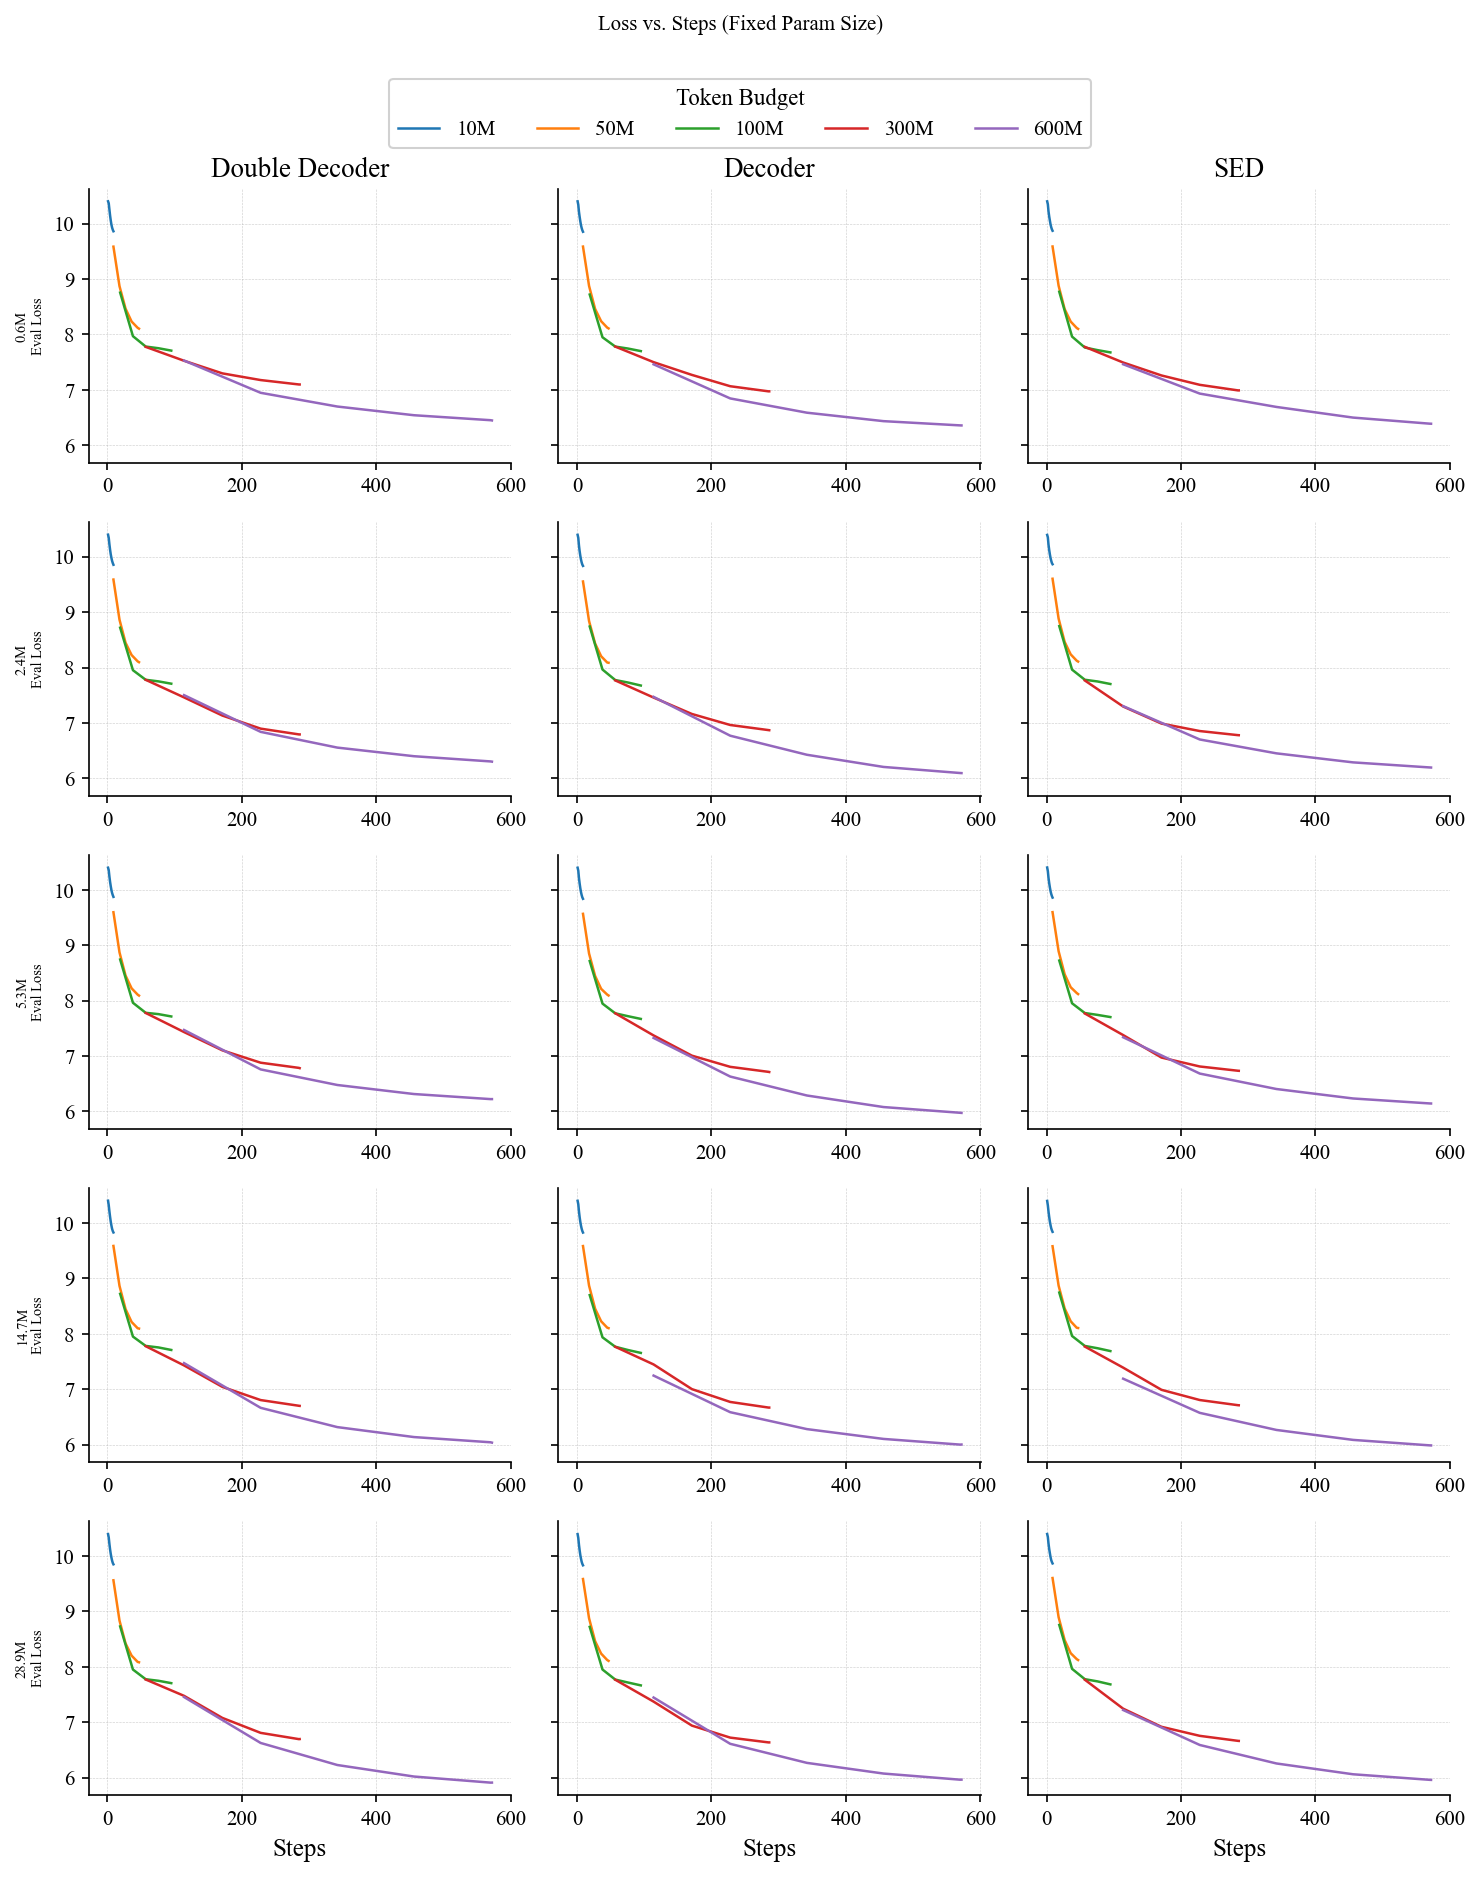

In [133]:
fig, axes = plt.subplots(5, 3, figsize=(10, 12), sharey=True, sharex=False)

for col, (model_type, param_type) in enumerate(zip(model_types, params_org)):
    for row, size_label in enumerate(param_type):
        ax = axes[row, col]
        for i, token in enumerate(tokens):
            curve  = data[token][size_label]["eval_curve"]
            steps  = [pt[0] for pt in curve]
            losses = [pt[2] for pt in curve]
            ax.plot(steps, losses, color=colors[i], linewidth=1.2,
                    label=token if row == 0 else None)
        ax.grid(True, which="both", linestyle="--", linewidth=0.3, alpha=0.6)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        if row == 0:
            ax.set_title(arch_labels.get(model_type, model_type))
        if col == 0:
            ax.set_ylabel(f"{size_label[3:]}\nEval Loss", fontsize=7)
        if row == 4:
            ax.set_xlabel("Steps")

handles, _ = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, tokens, title="Token Budget", loc="upper center",
           bbox_to_anchor=(0.5, 1.01), ncol=5, frameon=True, framealpha=0.9, edgecolor="0.8")
fig.suptitle("Loss vs. Steps (Fixed Param Size)", y=1.04, fontsize=10)
plt.tight_layout()
plt.show()

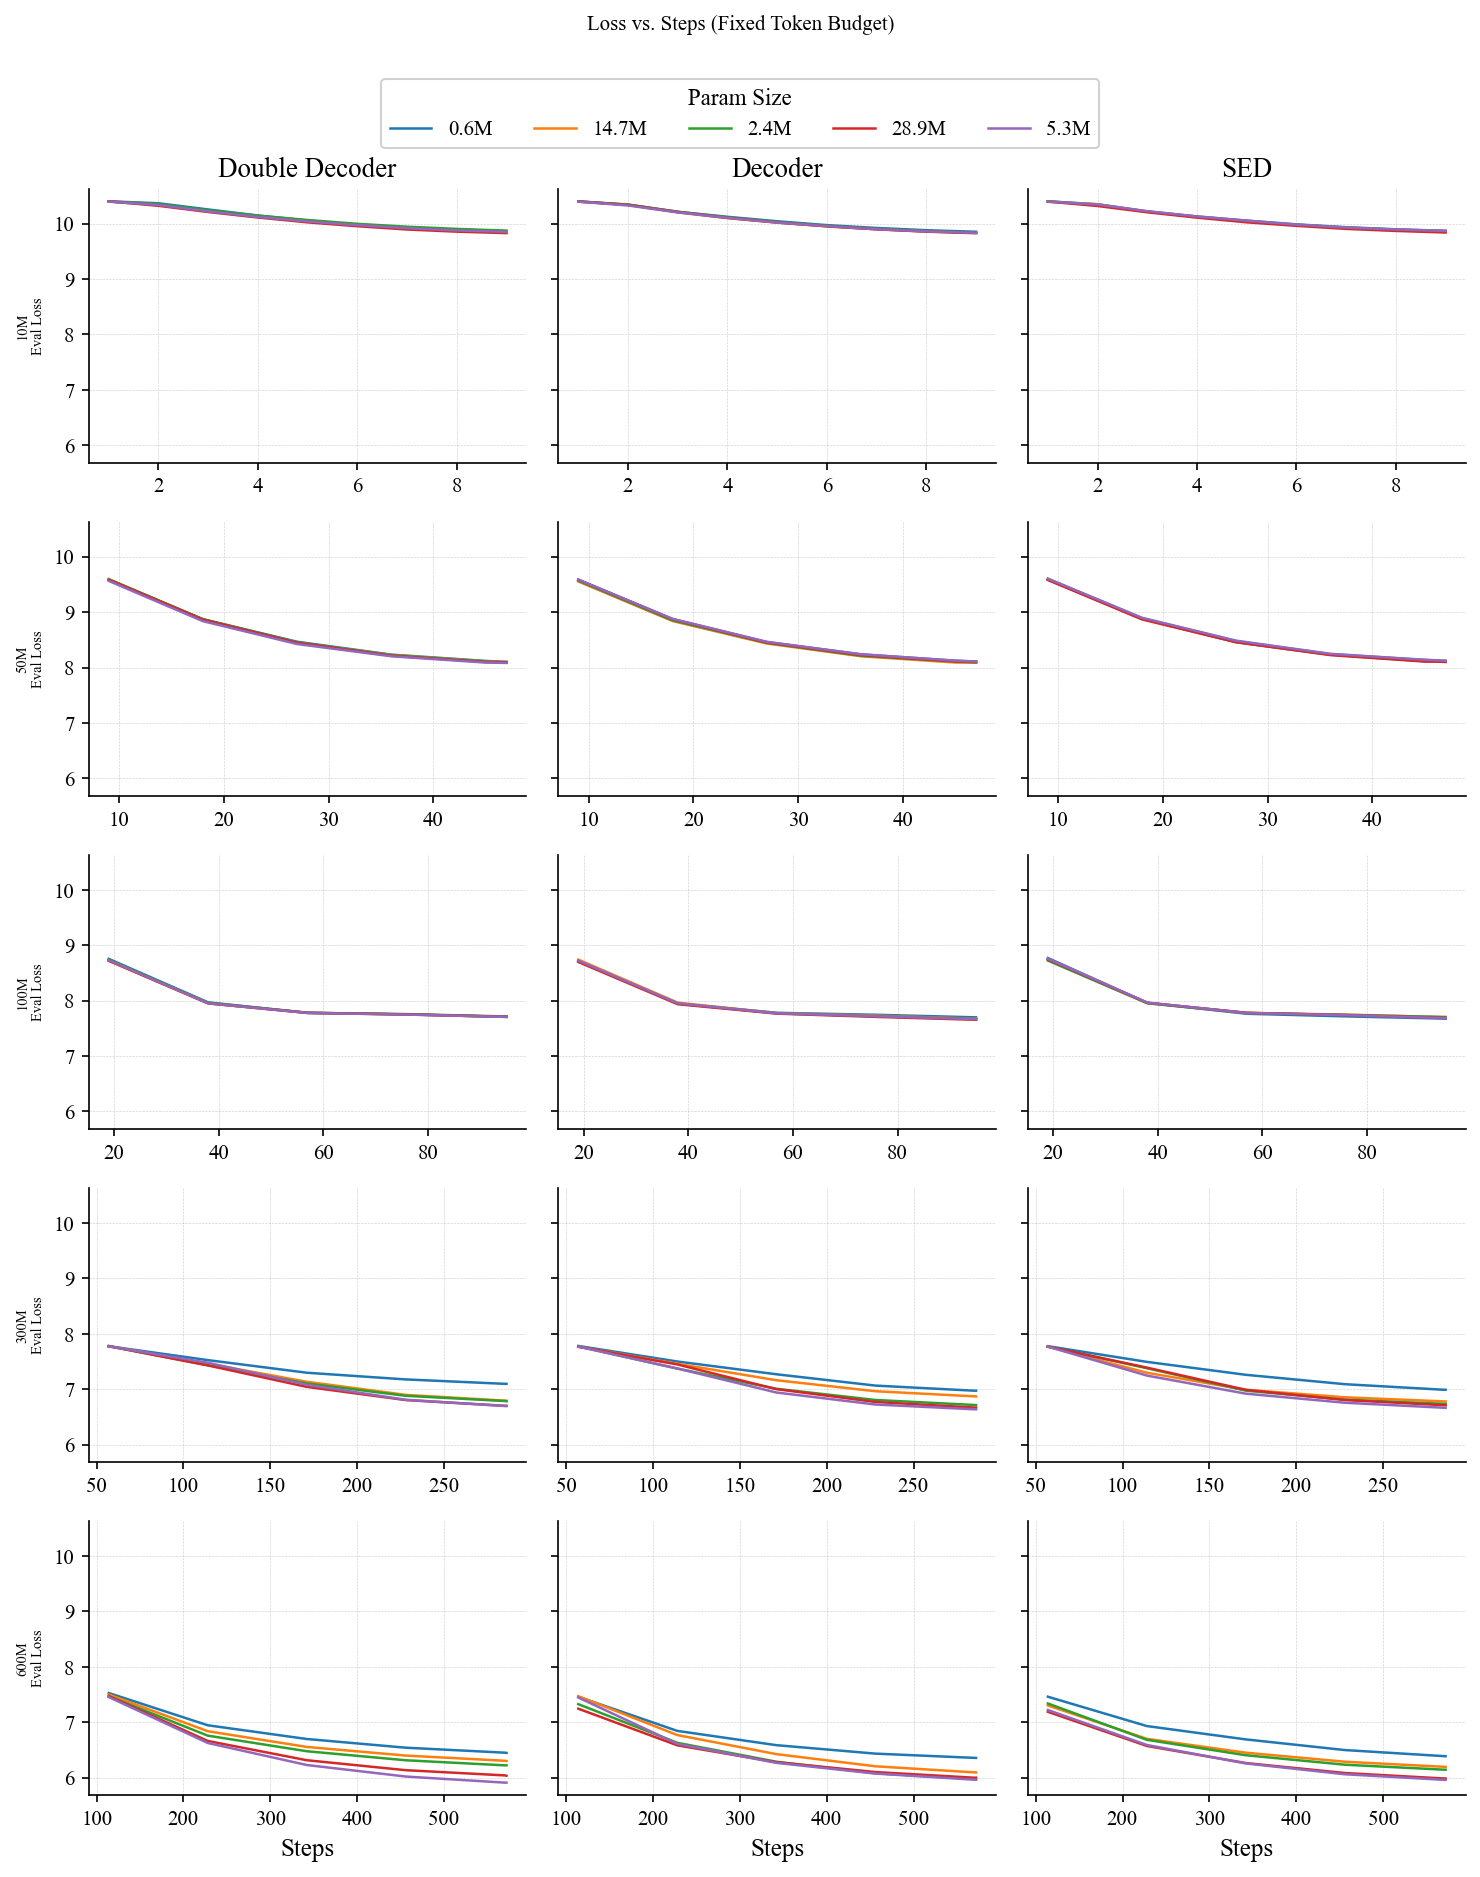

In [132]:
fig, axes = plt.subplots(5, 3, figsize=(10, 12), sharey=True, sharex=False)

for col, (model_type, param_type) in enumerate(zip(model_types, params_org)):
    for row, token in enumerate(tokens):
        ax = axes[row, col]
        for i, size_label in enumerate(param_type):
            curve  = data[token][size_label]["eval_curve"]
            steps  = [pt[0] for pt in curve]
            losses = [pt[2] for pt in curve]
            ax.plot(steps, losses, color=colors[i], linewidth=1.2,
                    label=size_label if row == 0 else None)
        ax.grid(True, which="both", linestyle="--", linewidth=0.3, alpha=0.6)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        if row == 0:
            ax.set_title(arch_labels.get(model_type, model_type))
        if col == 0:
            ax.set_ylabel(f"{token}\nEval Loss", fontsize=7)
        if row == 4:
            ax.set_xlabel("Steps")

handles, _ = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, params, title="Param Size", loc="upper center",
           bbox_to_anchor=(0.5, 1.01), ncol=5, frameon=True, framealpha=0.9, edgecolor="0.8")
fig.suptitle("Loss vs. Steps (Fixed Token Budget)", y=1.04, fontsize=10)
plt.tight_layout()
plt.show()